In [1]:
# main imports
import os
import numpy as np
from cartesio_planning import pycartesio_planning as pl
from xbot2_interface import pyxbot2_interface as xbi
from xbot2_interface import pyxbot2_collision as coll
from copy import deepcopy

np.set_printoptions(precision=2, suppress=True)

In [2]:
# load urdf, srdf
import nb_location
curr_dir = nb_location.get_nb_location()
urdf = open(curr_dir + '/../../test/resources/centauro_capsule.urdf', 'r').read()
srdf = open(curr_dir + '/../../test/resources/centauro_capsule.srdf', 'r').read()

In [3]:
# build model
model = xbi.ModelInterface2(urdf, srdf, 'pin')

fb_lim = np.array([1, 1, 1, 3, 3, 3])
qmin, qmax = deepcopy(model.getJointLimits())
qmin[:6] = -fb_lim
qmax[:6] = fb_lim
model.setJointLimits(qmin, qmax)

In [4]:
# wrap model into a state space for planning
ss = pl.StateSpace()
ss.addRobotConfigurationSpace(model)

0

In [5]:
# use state space to generate a random config
qrand = ss.random()
print(f'qrand = {qrand}')

qrand = [-0.06 -0.01  0.02 -0.02 -0.71 -0.65  0.27  0.86  0.88 -1.73  0.46 -2.48
 -1.    0.09 -1.89  1.24 -1.65 -0.43 -1.89  0.2   0.98  2.03 -1.13  0.06
  1.66  0.57 -0.84 -0.55  0.86  0.11 -0.05  2.26 -1.1  -0.96 -0.27  0.14
  0.48  1.39  2.01 -1.69 -0.76  0.92  2.15 -3.   -0.19  0.13 -2.24 -1.56
  0.49  2.01 -0.33 -0.96]


In [12]:
# create contact constraints
contact_map = {
    f'wheel_{i+1}': [0, 1, 2] for i in range(4)
}

contact = pl.ContactConstraint(model, contact_map, '')

contact.bind(ss)

ss.setConstraint(contact)

sample_q                  : 0%,  N = 933, 1.704e-06 < 2.07847e-06 +- 6.64727e-07 < 1.4498e-05
update_model_state        : 55%,  N = 214896, 4.354e-06 < 5.17455e-06 +- 4.47308e-07 < 4.2498e-05
state_valid               : 0%,  N = 214896, 1e-08 < 1.30289e-08 +- 5.19183e-09 < 1.697e-06
state_validity_check      : 57%,  N = 214896, 4.524e-06 < 5.3578e-06 +- 4.75281e-07 < 4.5702e-05
 └──collision_check       : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
    └──collision_near     : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
    └──collision_near_ok  : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
atlaschart::psi           : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
 └──psi_ok                : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
 └──linesearch            : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
constr_eval               : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
constr_jac                : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e

In [13]:
# change robot posture and use it to reset contact locations
qhome = model.getRobotState('home')
model.q = qhome
model.update()
contact.resetContactPose()

In [14]:
# sample a goal from constraint mainifold
qgoal = contact.sample()
print(f'constraint norm is {np.linalg.norm(contact.value(qgoal))}')

model.checkJointLimits(qgoal)

constraint norm is 1.9096450610436092e-05


True

In [20]:
# plan
planner = pl.Planner(state_space=ss)
planner.solve(qhome, qgoal, timeout=2, planner_type='RRTConnect')

sample_q                  : 0%,  N = 9, 0.000832377 < 0.000971096 +- 0.000275047 < 0.00174556
update_model_state        : 0%,  N = 1672, 4.513e-06 < 5.12805e-06 +- 4.47429e-07 < 1.6688e-05
state_valid               : 0%,  N = 1672, 1.1e-08 < 1.35502e-08 +- 1.65719e-09 < 3.3e-08
state_validity_check      : 0%,  N = 1672, 4.753e-06 < 5.54541e-06 +- 5.45993e-07 < 1.932e-05
 └──collision_check       : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
    └──collision_near     : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
    └──collision_near_ok  : 0%,  N = 0, 1.79769e+308 < 0 +- 0 < -1.79769e+308
atlaschart::psi           : 80%,  N = 2354, 5.568e-05 < 0.000706641 +- 0.000171946 < 0.00156313
 └──psi_ok                : 0%,  N = 2354, 1.1e-08 < 1.49439e-08 +- 2.95237e-09 < 6.4e-08
 └──linesearch            : 1%,  N = 2235, 1.5571e-05 < 1.67596e-05 +- 1.15197e-06 < 3.9657e-05
constr_eval               : 2%,  N = 4615, 5.157e-06 < 1.00213e-05 +- 1.1137e-06 < 3.1794e-05
constr_jac       

diocane
diocane


True

In [21]:
# get solution
trj = planner.getSolutionPath()

# interpolate
time, pos, vel, acc = pl.simpleTrajectoryInterpolation(ss, trj, 1., 1., 0.01)

# evaluate constraint on interpolated trajectory
constr = [contact.value(q) for q in pos.T]

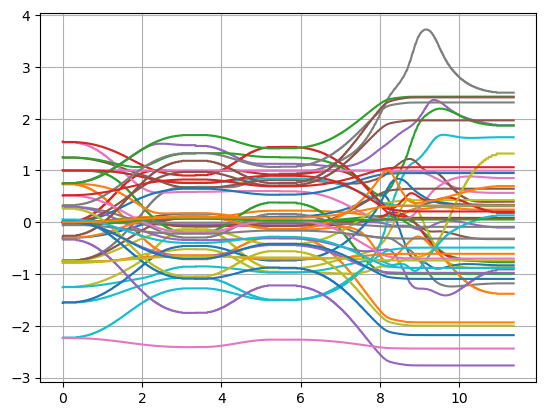

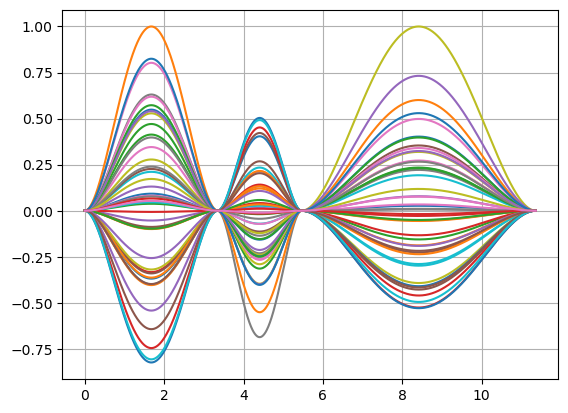

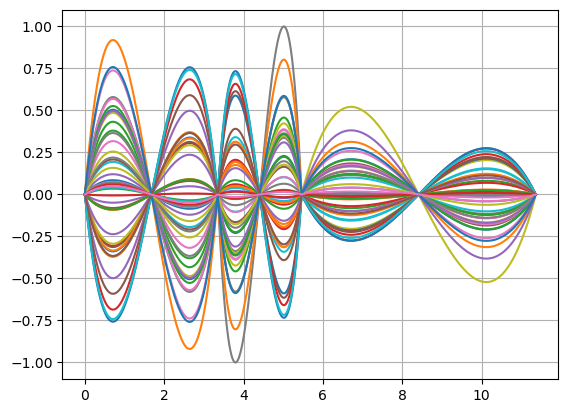

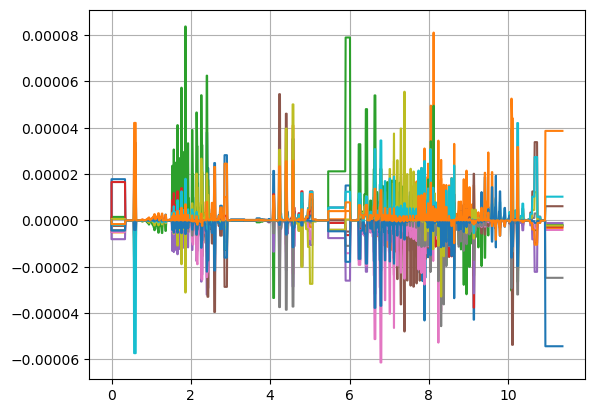

In [22]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt

plt.figure()
axes = plt.plot(time, pos.T)
plt.grid()

plt.figure()
axes = plt.plot(time, vel.T)
plt.grid()

plt.figure()
axes = plt.plot(time, acc.T)
plt.grid()

plt.figure()
axes = plt.plot(time, constr)
plt.grid()